# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [98]:
df = pd.read_csv("Dados/ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [99]:
df.dtypes

Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object

In [100]:
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

Tudo certo com o DataFrame...

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

## Tratamento de Outliers

In [101]:
df.describe()


,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


### N_Quartos

In [102]:
fig = px.box(
    df['N_Quartos'],
    height = 400,
    width = 1000
)

fig.show()

In [103]:
df[df['N_Quartos'] > 6]

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6766,8000,0,273,10,4,1,8
6841,8700,5040,852,7,6,5,6


Olhando para a metragem dessa casa, entendo que provavelmente é um erro de digitação essa casa ter 10 quartos, portanto, vou optar pela exclusão desse registro por ser o único com essa característica.

In [104]:
df.drop(df[df['N_Quartos'] == 10].index, axis = 0, inplace = True)

Validando a exclusão...

In [105]:
df[df['N_Quartos'] > 6]

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6841,8700,5040,852,7,6,5,6


### N_Banheiros

In [106]:
fig = px.box(
    df['N_banheiros'],
    height = 400,
    width = 1000
)

fig.show()

In [107]:
df[(df['N_banheiros'] > 6)]

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
5825,4000,1123,160,3,7,3,3
6031,4500,3300,250,4,7,4,4
6531,6000,0,313,5,8,4,4
7082,14000,5800,400,6,8,2,2
7128,16000,2800,370,5,7,4,5


Considerando a metragem das casas com 7 a 8 banheiros, entendo que possívelmente foi um erro de digitação, e considerando o tamanho do DataFrame, vou optar pela exclusão desses registros.



In [108]:
df.drop(df[df['N_banheiros'] >= 7].index, axis = 0, inplace = True)

Validando a exclusão...

In [109]:
df[(df['N_banheiros'] >= 7)]

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas


### N_Vagas

In [110]:
fig = px.box(
    df['N_Vagas'],
    height = 400,
    width = 1000
)

fig.show()

In [111]:
df[df['N_Vagas'] > 6]

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
7131,16000,4800,425,5,6,5,7
7196,25000,3320,222,4,5,4,9
7200,25000,3700,266,3,4,3,7
7201,25000,6000,600,4,5,4,8


Olhando a metragem dos imóveis de 222 e 266, entendo que provávelmente são erros de digitação pelo alto número de vagas, também vou seguir com a exclusão desses valores ainda em mente por ser um DataFrame robusto.



In [112]:
df[(df['N_Vagas'] >= 7) & (df['Metragem'] < 300)]

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
7196,25000,3320,222,4,5,4,9
7200,25000,3700,266,3,4,3,7


In [113]:
df.drop(df[(df['N_Vagas'] >= 7) & (df['Metragem'] < 300)].index, axis = 0, inplace = True)

Validando a exclusão...

In [114]:
df[df['N_Vagas'] > 6]

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
7131,16000,4800,425,5,6,5,7
7201,25000,6000,600,4,5,4,8


### Usando o DESCRIBE() novamente

In [115]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7195.000000,7195.00000,7195.000000,7195.000000,7195.000000,7195.000000,7195.000000
mean,2955.648645,809.65476,88.291313,2.297151,2.091313,1.014315,1.437526
std,2919.541925,792.53840,61.215159,0.819105,0.973160,0.871149,0.857571
min,480.000000,0.00000,30.000000,1.000000,1.000000,0.000000,0.000000
25%,1350.000000,395.00000,52.000000,2.000000,2.000000,1.000000,1.000000
50%,2000.000000,592.00000,67.000000,2.000000,2.000000,1.000000,1.000000
75%,3200.000000,980.00000,100.000000,3.000000,2.000000,1.000000,2.000000
max,25000.000000,9500.00000,880.000000,7.000000,6.000000,5.000000,8.000000


## Análise Bivariada

Metragem x Valor Aluguel x Condominio


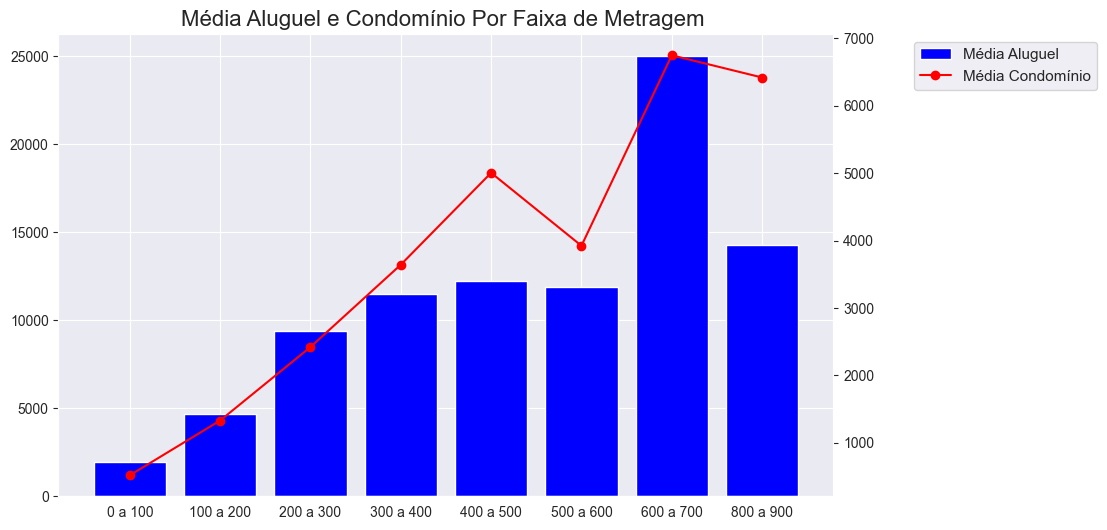

In [116]:
df_2 = df.copy()

# DEFININDO AS FAIXAS DE METRAGEM
max = df_2['Metragem'].max()
bins = list(range(0, max + 100, 100))
labels = [f'{b} a {b + 100}' for b in bins[:-1]]

# CRIANDO AS FAIXAS
df_2['Faixas_Metragem'] = pd.cut(
    df_2['Metragem'],
    bins = bins,
    labels = labels,
    right = False,
    include_lowest = True
)

# TIRANDO A MÉDIA DE ALUGUEL POR FAIXA DE IMÓVEL
media_alugueis = df_2.groupby('Faixas_Metragem')['Valor_Aluguel'].mean().round().sort_index().reset_index(name = 'Média')

# TIRANDO A MÉDIA DE CONDOMÍNIO POR FAIXA DE METRAGEM DO IMÓVEL
media_condominio = df_2.groupby('Faixas_Metragem')['Valor_Condominio'].mean().round().sort_index().reset_index(name = 'Média')

fig, ax1 = plt.subplots(figsize = (10, 6))

# GRÁFICO DE BARRAS
ax1.bar(
    media_alugueis['Faixas_Metragem'],
    media_alugueis['Média'],
    color = 'blue',
    label = 'Média Aluguel'
)

# GRÁFICO DE LINHAS
ax2 = ax1.twinx()
ax2.plot(
    media_condominio['Faixas_Metragem'],
    media_condominio['Média'],
    color = 'red',
    marker = 'o',
    label = 'Média Condomínio'
)

# LEGENDA
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'upper right', bbox_to_anchor = (1.35, 1), fontsize = 11)

plt.title("Média Aluguel e Condomínio Por Faixa de Metragem ", fontsize = 16)
plt.grid(False)
plt.show()


Conforme o tamanho do imóvel aumenta, maior tende a ser o aluguel e o condomínio do mesmo.

Os imóveis com maiores aluguéis, tendem a estar entre 600 a 700 m2.

Média Valor Aluguel x Número de Vagas

Text(0, 0.5, 'N. Vagas')

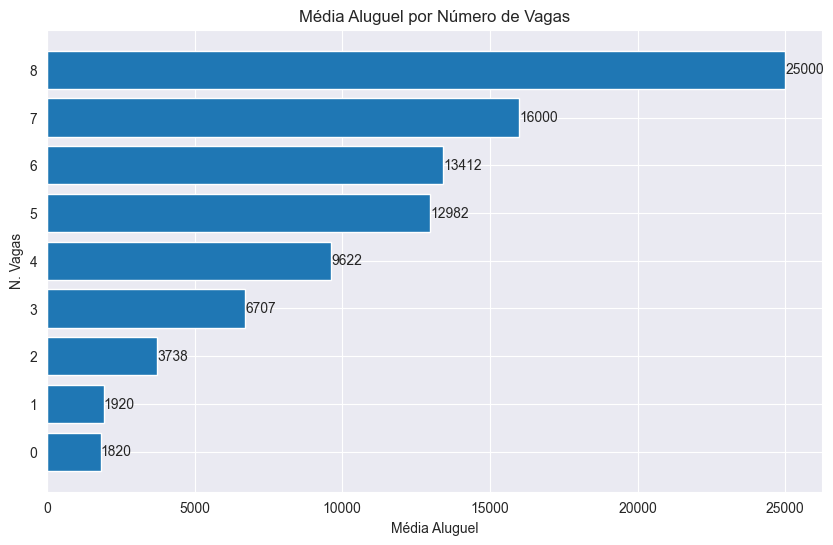

In [117]:
# MÉDIA ALUGUEL POR NÚMERO DE VAGAS
media_aluguel = df.groupby('N_Vagas')['Valor_Aluguel'].mean().reset_index(name = 'Média')
media_aluguel['N_Vagas'] = media_aluguel['N_Vagas'].astype(str)

plt.figure(figsize = (10, 6))

plt.barh(
    media_aluguel['N_Vagas'],
    media_aluguel['Média']
)

for i, valor in enumerate(media_aluguel['Média']):
    plt.text(
        valor,        # posição no eixo X
        i,            # posição no eixo Y
        f'{valor:.0f}',  # formatação (sem casas decimais, opcional)
        va = 'center'
    )

plt.title('Média Aluguel por Número de Vagas')
plt.xlabel('Média Aluguel')
plt.ylabel('N. Vagas')

#### **Insight:**

Quanto maior o número de vagas ofertados pelo imóvel, maior tende a ser seu aluguel.

Text(0, 0.5, 'N_Suites')

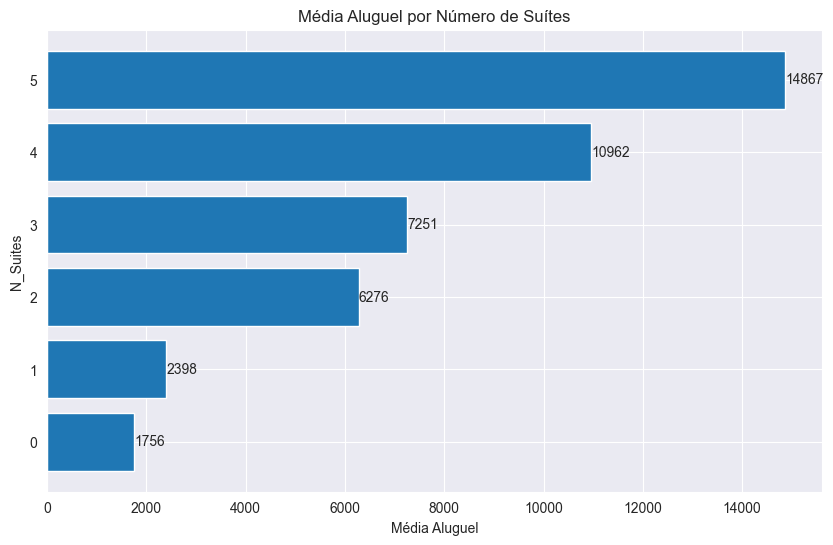

In [118]:
# MÉDIA ALUGUEL POR NÚMERO DE VAGAS
media_aluguel = df.groupby('N_Suites')['Valor_Aluguel'].mean().reset_index(name = 'Média')
media_aluguel['N_Suites'] = media_aluguel['N_Suites'].astype(str)

plt.figure(figsize = (10, 6))

plt.barh(
    media_aluguel['N_Suites'],
    media_aluguel['Média']
)

for i, valor in enumerate(media_aluguel['Média']):
    plt.text(
        valor,        # posição no eixo X
        i,            # posição no eixo Y
        f'{valor:.0f}',  # formatação (sem casas decimais, opcional)
        va = 'center'
    )

plt.title('Média Aluguel por Número de Suítes')
plt.xlabel('Média Aluguel')
plt.ylabel('N_Suites')

#### **Insight:**

Quanto maior o número de suítes, maior tende a ser o valor do aluguel.

Ponto de atenção: o número de quartos é altamente correlato com a metragem do imóvel, portanto pode ser efeito de causalidade.

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




Tabela de Correlação

In [119]:
df.corr()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
Valor_Aluguel,1.000000,0.694732,0.730594,0.411134,0.603632,0.613845,0.648079
Valor_Condominio,0.694732,1.000000,0.806832,0.499491,0.585163,0.588992,0.696219
Metragem,0.730594,0.806832,1.000000,0.676206,0.684061,0.695210,0.745252
N_Quartos,0.411134,0.499491,0.676206,1.000000,0.551013,0.542021,0.587841
N_banheiros,0.603632,0.585163,0.684061,0.551013,1.000000,0.922241,0.696652
N_Suites,0.613845,0.588992,0.695210,0.542021,0.922241,1.000000,0.713924
N_Vagas,0.648079,0.696219,0.745252,0.587841,0.696652,0.713924,1.000000


Heatmap de Correlação


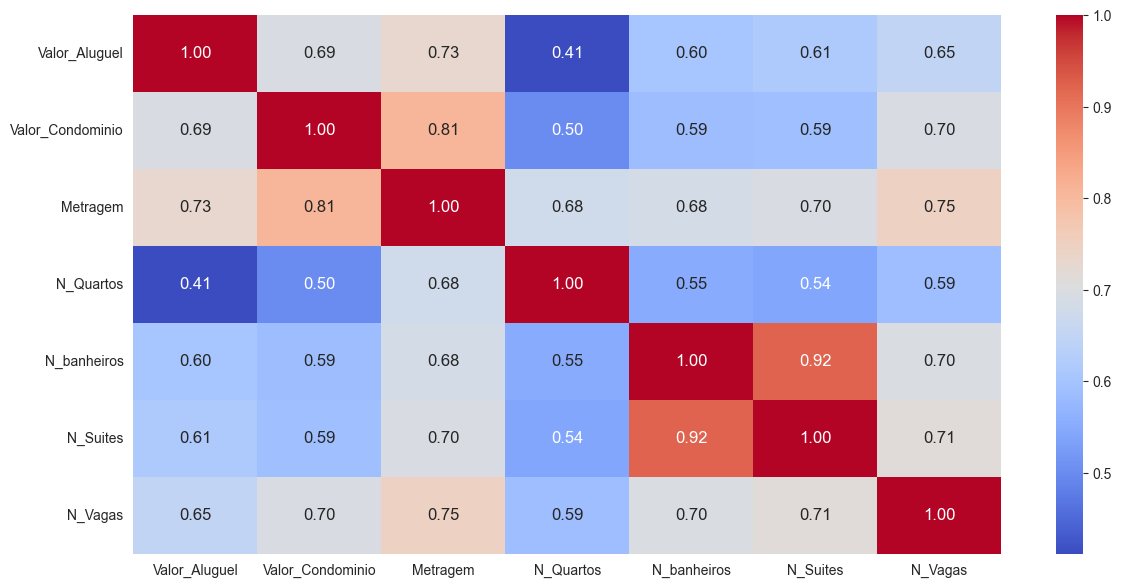

In [120]:
matriz_corr = df.corr()

plt.figure(figsize = (14, 7))
sns.heatmap(
    matriz_corr,
    annot = True, # rótulo de dados
    cmap ='coolwarm', # cor de template
    annot_kws = {'size': 12}, # tamanho da fonte
    fmt = '.2f' # casas decimais
)

plt.show()

Principais relações:

- Condomínio x Metragem
- Aluguel x Metragem
- Metragem x Número Vagas
- Aluguel x Condomínio (possívelmente pelo padrão e metragem do imóvel)
- Condomínio x Número Vagas


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [121]:
x = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variável valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [122]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

In [123]:
# VERIFICANDO AS BASES
print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

x_train: (5396, 6)
x_test: (1799, 6)
y_train: (5396,)
y_test: (1799,)


# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [124]:
x_M1 = x_train[['Metragem']]  # Variável independente (características)
y_M1 = y_train  # Variável dependente (rótulo)


In [125]:
regressao_simples_metragem = LinearRegression()

regressao_simples_metragem.fit(x_M1, y_M1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [126]:
regressao_simples_metragem.intercept_

np.float64(-92.88834676282477)

In [127]:
regressao_simples_metragem.coef_

array([34.52143656])

Aluguel = Coeficiente Angular * (Metragem) + Coeficiente Linear

Nossa equação seria: Aluguel = 34,52 * (Metragem) - 92,88

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [128]:
regressao_simples_metragem.score(x_M1, y_M1)

0.5301851816575862

#### **Insight:**

Apenas 53% da variação dos aluguéis é explicada pela metragem dos imóveis. Portanto, não é possível prever o valor do aluguel com apenas a metragem do imóvel.

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

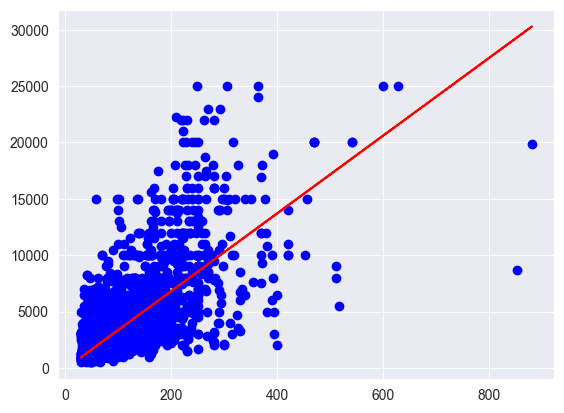

In [129]:
# Pontos dos dados reais
plt.scatter(
    x_M1, # METRAGEM
    y_M1, # ALUGUEL
    color= 'blue',
    label = 'Dados Originais'
)

# Linha de regressão
plt.plot(
    x_M1, # METRAGEM
    regressao_simples_metragem.predict(x_M1), # ALUGUEL PREDITO
    color = 'red',
    label = 'Linha de Regressão'
)

plt.show()

#### **Insight:**

Analisando o gráfico, a variável metragem indica baixo poder explicativo devido a alta dispersão dos aluguéis por faixa de metragem, portanto, não é possível prever o aluguel dos imóveis utilizando apenas essa variável.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [130]:
x_test_M1 = x_test[['Metragem']]  # Variável independente (características)
y_test_M1 = y_test  # Variável dependente (rótulo)

In [137]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = regressao_simples_metragem.predict(x_test_M1)

# Avaliando o desempenho do modelo usando métricas como o R²
r2_simples = regressao_simples_metragem.score(x_test_M1, y_test_M1)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.6204887553217753


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

A variação foi praticamente nula (cerca de 3%), entendo que não é possível afirmar que o modelo está subajustado e sim que está consiste e que consegue generalizar relativamente bem, mesmo que a variável utilizada não seja a ideal para a previsão.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [132]:
x_M2 = x_train
y_M2 = y_train

B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [133]:
regressao_multipla = LinearRegression()

regressao_multipla.fit(x_M2, y_M2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [134]:
regressao_multipla.score(x_M2, y_M2)

0.6005449466442091

Pelo desempenho apresentado, a base explica cerca de 60% da variação do valor dos aluguéis, portanto, a base se mostrou pouco explicativa em relação a variável target

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [139]:
x_test_M2 = x_test
y_test_M2 = y_test

previsao = regressao_multipla.predict(x)
r2_multiplo = regressao_multipla.score(x_test_M2, y_test_M2)

print("Regressão Simples")
print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2_simples)

print("\nRegressão Múltipla")
print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2_multiplo)

Regressão Simples
Coeficiente de Determinação (R²) nos Dados de Teste: 0.5446162056247699

Regressão Múltipla
Coeficiente de Determinação (R²) nos Dados de Teste: 0.6204887553217753


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

Definitivamente a regressão múltipla desempenhou melhor, com cerca de 62% de explicação.

Devido a inclusão de novas variáveis relevantes no modelo, aprimorando a capacidade preditiva. Embora o desempenho tenha melhorado, ainda não é possível fazer previsões assertivas com essa base de dados.